In [ ]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np

from gridcp.calibration import calibrate_threshold_false_alarm_from_data
from gridcp.detector import GridDetector
from gridcp.scores import ExponentialFamilyGLR, NPFOCuS

GRB_FILE = "../data-NPFOCuS/grb171004857.pickle"
DATA_DIR = "../data-NPFOCuS"
GRB_FNAME = "grb171004857.pickle"
OUTPUT_PATH = "npfocus_grb_bootstrap_detection.png"
RESET_OUTPUT_PATH = "npfocus_grb_bootstrap_detection_reset_at_cp.png"

with open(GRB_FILE, "rb") as fh:
    t, counts_dict, trigger_t, trigger_str = pickle.load(fh)

t_mid = (t[:-1] + t[1:]) / 2
channels = list(counts_dict.keys())
grb_matrix = np.column_stack([counts_dict[c] for c in channels]).astype(np.float64)
grb_total = grb_matrix.sum(axis=1)

print(f"Trigger: {trigger_str}")
print(f"Bins: {len(t_mid)}, Channels: {channels}")

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(13, 14), constrained_layout=True)

all_fnames = sorted(f for f in os.listdir(DATA_DIR) if f.endswith(".pickle"))
for ax, fname in zip(axes, all_fnames):
    with open(os.path.join(DATA_DIR, fname), "rb") as fh:
        t_f, counts_f, _, trigger_str_f = pickle.load(fh)
    t_mid_f = (t_f[:-1] + t_f[1:]) / 2
    total_f = np.column_stack(list(counts_f.values())).sum(axis=1)
    ax.step(t_mid_f, total_f, where="mid", linewidth=0.8)
    ax.set_title(f"{fname}  —  trigger: {trigger_str_f}", fontsize=9)
    ax.set_ylabel("Total counts")
    ax.ticklabel_format(useOffset=False, axis="x")

axes[-1].set_xlabel("Time (MET s)")
fig.suptitle("All pickle files — total counts", fontsize=12)
plt.show()

# GRB Detector Analysis

This notebook now mirrors the consolidated script workflow: load the GRB and background data, reuse the calibrated thresholds, run both detectors, and plot both the standard crossing-based events and the reset-at-estimated-changepoint results.

In [ ]:
bg_blocks = []
for fname in sorted(f for f in os.listdir(DATA_DIR) if f.endswith(".pickle")):
    if fname == GRB_FNAME:
        continue
    with open(os.path.join(DATA_DIR, fname), "rb") as fh:
        _, counts_bg, _, _ = pickle.load(fh)
    ch_bg = list(counts_bg.keys())
    bg_blocks.append(
        np.column_stack([counts_bg[c] for c in ch_bg]).astype(np.float64)
    )

background_data = np.concatenate(bg_blocks, axis=0)
background_total = background_data.sum(axis=1, keepdims=True)
poisson_theta_init = float(np.log(background_total.mean()))

glr_score = ExponentialFamilyGLR.from_family(
    "poisson",
    n_features=1,
    theta_init=poisson_theta_init,
    enable_penalty=True,
)
npfocus_half_width = max(160.0, float(np.max(np.abs(background_data - 160.0))))
value_grid = np.arange(
    160.0 - npfocus_half_width,
    160.0 + npfocus_half_width + 1.0,
    dtype=np.float64,
)
npfocus_score_obj = NPFOCuS(
    value_grid=value_grid,
    n_features=background_data.shape[1],
    enable_penalty=True,
)

print("poisson_theta_init", poisson_theta_init)

## Calibration

Thresholds are estimated by the circular block bootstrap (Politis & Romano, 1992) applied to pre-trigger background data. Each background pickle file is a 60 s window centered on a Fermi/GBM trigger; the first 30 s (bins 0–298) is pre-trigger and treated as change-free training data. The four files contribute 4 × 299 = 1196 bins of background.

In [ ]:
TRIGGER_BIN = 299
FALSE_ALARM_PROB = 0.05
N_PATHS = 1000

bg_fnames = sorted(
    f for f in os.listdir(DATA_DIR) if f.endswith(".pickle") and f != GRB_FNAME
)

glr_cal_chunks = []
npf_cal_chunks = []
for fname in bg_fnames:
    with open(os.path.join(DATA_DIR, fname), "rb") as fh:
        _, counts_bg, _, _ = pickle.load(fh)
    mat = np.column_stack(list(counts_bg.values())).astype(np.float64)
    pre = mat[:TRIGGER_BIN]
    glr_cal_chunks.append(pre.sum(axis=1, keepdims=True))
    npf_cal_chunks.append(pre)

glr_training = np.concatenate(glr_cal_chunks, axis=0)
npf_training = np.concatenate(npf_cal_chunks, axis=0)
stream_len = len(grb_total)

GLR_THRESHOLD = calibrate_threshold_false_alarm_from_data(
    glr_score,
    glr_training,
    false_alarm_probability=FALSE_ALARM_PROB,
    stream_len=stream_len,
    n_paths=N_PATHS,
    rng=0,
)
NPFOCUS_THRESHOLD = calibrate_threshold_false_alarm_from_data(
    npfocus_score_obj,
    npf_training,
    false_alarm_probability=FALSE_ALARM_PROB,
    stream_len=stream_len,
    n_paths=N_PATHS,
    rng=0,
)

threshold_floor = np.finfo(np.float64).eps
glr_det = GridDetector(
    score=glr_score,
    threshold=np.maximum(GLR_THRESHOLD, threshold_floor),
)
npf_det = GridDetector(
    score=npfocus_score_obj,
    threshold=np.maximum(NPFOCUS_THRESHOLD, threshold_floor),
)

print(f"Training: {len(glr_training)} bins from {len(bg_fnames)} background files (pre-trigger only)")
print(f"Stream length: {stream_len}, false alarm prob: {FALSE_ALARM_PROB}, n_paths: {N_PATHS}")
print(f"GLR threshold:     {GLR_THRESHOLD}")
print(f"NPFOCuS threshold: {NPFOCUS_THRESHOLD}")

## Detector Helpers

The helper functions below are copied from the script so the notebook produces the same event extraction and reset behavior.

In [3]:
def run_detector_with_crossing_events(detector, stream, threshold):
    state = detector.init_state()
    trace = []
    changepoint_indices = []
    alarm_start_indices = []
    alarm_end_indices = []
    selected_stat_indices = []
    was_active = False

    for stream_idx, x in enumerate(stream):
        obs = np.array([x], dtype=np.float64) if np.isscalar(x) else x
        state, out = detector.update(state, obs)
        trace.append(out["max_score"].astype(np.float64, copy=True))
        is_active = bool(np.any(out["max_score"] > threshold))

        if is_active and not was_active:
            crossed = np.flatnonzero(out["max_score"] > threshold)
            stat_idx = int(crossed[0]) if crossed.size else int(np.argmax(out["max_score"]))
            changepoint_indices.append(int(out["max_split_point"][stat_idx]))
            alarm_start_indices.append(stream_idx)
            selected_stat_indices.append(stat_idx)
        elif was_active and not is_active:
            alarm_end_indices.append(stream_idx)

        was_active = is_active

    return (
        np.stack(trace),
        changepoint_indices,
        alarm_start_indices,
        alarm_end_indices,
        selected_stat_indices,
    )


def run_detector_with_reset_at_changepoint(detector, stream, threshold):
    n_obs = len(stream)
    score_dim = detector.score.n_scores
    trace = np.full((n_obs, score_dim), np.nan, dtype=np.float64)
    changepoint_indices = []
    alarm_indices = []
    selected_stat_indices = []
    segment_start = 0

    while segment_start < n_obs:
        state = detector.init_state()
        found_alarm = False

        for stream_idx in range(segment_start, n_obs):
            x = stream[stream_idx]
            obs = np.array([x], dtype=np.float64) if np.isscalar(x) else x
            state, out = detector.update(state, obs)
            trace[stream_idx] = out["max_score"].astype(np.float64, copy=True)

            if not out["alarm"]:
                continue

            crossed = np.flatnonzero(out["max_score"] > threshold)
            stat_idx = int(crossed[0]) if crossed.size else int(np.argmax(out["max_score"]))
            cp_idx = segment_start + int(out["max_split_point"][stat_idx])
            cp_idx = min(max(cp_idx, segment_start), n_obs - 1)

            changepoint_indices.append(cp_idx)
            alarm_indices.append(stream_idx)
            selected_stat_indices.append(stat_idx)

            next_start = max(cp_idx, segment_start + 1)
            if next_start >= n_obs:
                segment_start = n_obs
            else:
                segment_start = next_start
            found_alarm = True
            break

        if not found_alarm:
            break

    return trace, changepoint_indices, alarm_indices, selected_stat_indices

## Run Detectors

This section runs the two detectors on the GRB stream, selects the active NPFOCuS statistic, and also computes the reset-at-estimated-changepoint traces.

In [4]:
glr_trace, glr_cp_indices, glr_alarm_start_indices, glr_alarm_end_indices, glr_stat_indices = run_detector_with_crossing_events(
    glr_det,
    grb_total,
    GLR_THRESHOLD,
 )
glr_trace_selected = glr_trace[:, 0]

npf_trace, npf_cp_indices, npf_alarm_start_indices, npf_alarm_end_indices, npf_stat_indices = run_detector_with_crossing_events(
    npf_det,
    grb_matrix,
    NPFOCUS_THRESHOLD,
 )
npf_trace_sum = npf_trace[:, 0]
npf_trace_max = npf_trace[:, 1]
npf_trace_selected = npf_trace_sum if not npf_stat_indices or npf_stat_indices[0] == 0 else npf_trace_max
npf_threshold_selected = NPFOCUS_THRESHOLD[0] if not npf_stat_indices or npf_stat_indices[0] == 0 else NPFOCUS_THRESHOLD[1]
npf_triggered_stat = "sum" if not npf_stat_indices or npf_stat_indices[0] == 0 else "max"

print("glr_alarm_start_indices", glr_alarm_start_indices, "glr_alarm_end_indices", glr_alarm_end_indices)
print("npf_alarm_start_indices", npf_alarm_start_indices, "npf_alarm_end_indices", npf_alarm_end_indices, "npf_stat", npf_triggered_stat)

glr_alarm_start_indices [307] glr_alarm_end_indices [335]
npf_alarm_start_indices [305] npf_alarm_end_indices [332] npf_stat sum


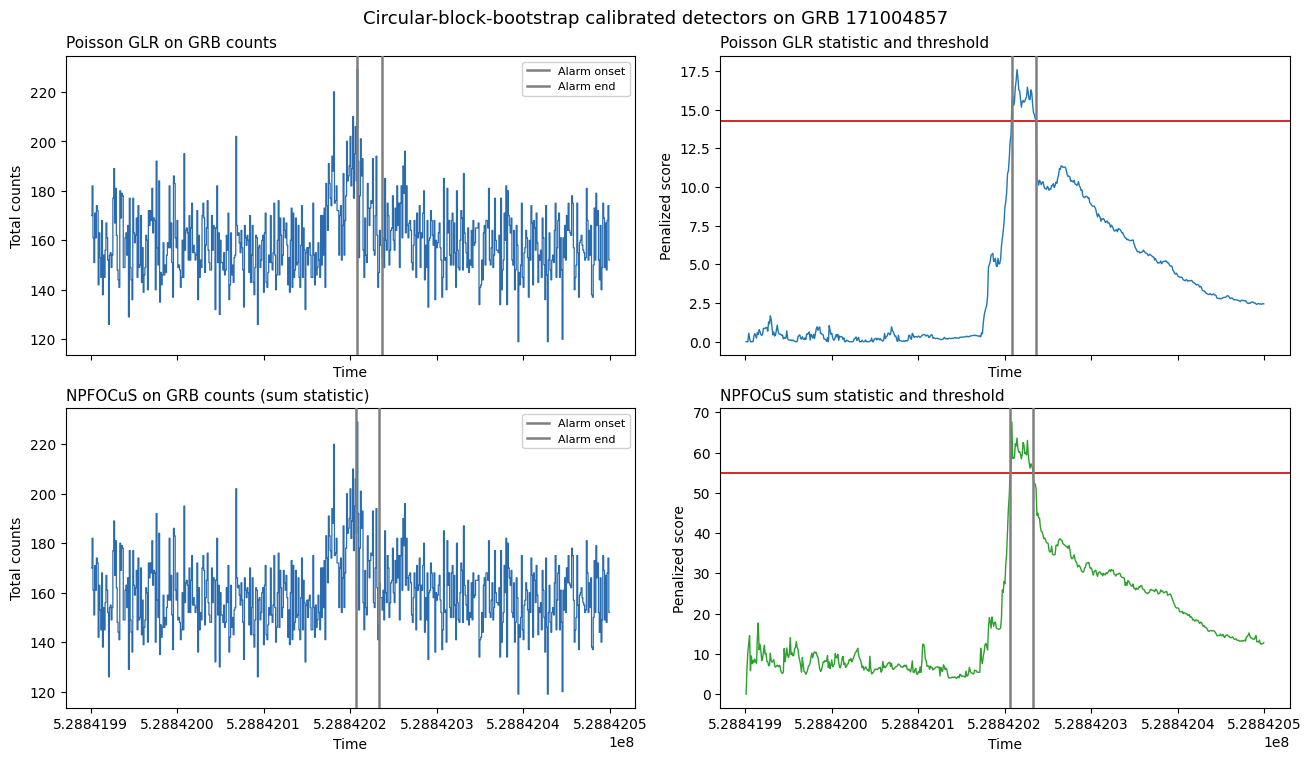

In [6]:
threshold_color = "#d62728"
score_color_glr = "#1f77b4"
score_color_npf = "#2ca02c"
alarm_end_color = "#7f7f7f"
alarm_line_style = "-"
alarm_line_width = 1.8
count_color = "#2b6cb0"


def draw_event_lines(ax, alarm_start_indices, alarm_end_indices):
    for idx, alarm_idx in enumerate(alarm_start_indices):
        ax.axvline(
            t_mid[alarm_idx],
            color=alarm_end_color,
            linestyle=alarm_line_style,
            linewidth=alarm_line_width,
            label="Alarm onset" if idx == 0 else None,
            zorder=4,
        )
    for idx, alarm_idx in enumerate(alarm_end_indices):
        ax.axvline(
            t_mid[alarm_idx],
            color=alarm_end_color,
            linestyle=alarm_line_style,
            linewidth=alarm_line_width,
            label="Alarm end" if idx == 0 else None,
            zorder=3,
        )


def draw_count_panel(ax, alarm_start_indices, alarm_end_indices, title):
    ax.step(t_mid, grb_total, where="mid", color=count_color, linewidth=0.9)
    draw_event_lines(ax, alarm_start_indices, alarm_end_indices)
    ax.set_ylabel("Total counts")
    ax.set_title(title, loc="left", fontsize=11)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        dedup = dict(zip(labels, handles))
        ax.legend(dedup.values(), dedup.keys(), loc="upper right", fontsize=8, framealpha=0.9)


fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex="col", constrained_layout=True)

draw_count_panel(
    axes[0, 0],
    glr_alarm_start_indices,
    glr_alarm_end_indices,
    "Poisson GLR on GRB counts",
 )
draw_count_panel(
    axes[1, 0],
    npf_alarm_start_indices,
    npf_alarm_end_indices,
    f"NPFOCuS on GRB counts ({npf_triggered_stat or 'sum'} statistic)",
 )

axes[0, 1].plot(t_mid, glr_trace_selected, color=score_color_glr, linewidth=1.0)
axes[0, 1].axhline(GLR_THRESHOLD[0], color=threshold_color, linewidth=1.4)
draw_event_lines(axes[0, 1], glr_alarm_start_indices, glr_alarm_end_indices)
axes[0, 1].set_ylabel("Penalized score")
axes[0, 1].set_title("Poisson GLR statistic and threshold", loc="left", fontsize=11)

axes[1, 1].plot(t_mid, npf_trace_selected, color=score_color_npf, linewidth=1.0)
axes[1, 1].axhline(npf_threshold_selected, color=threshold_color, linewidth=1.4)
draw_event_lines(axes[1, 1], npf_alarm_start_indices, npf_alarm_end_indices)
axes[1, 1].set_ylabel("Penalized score")
axes[1, 1].set_title(
    f"NPFOCuS {npf_triggered_stat or 'sum'} statistic and threshold",
    loc="left",
    fontsize=11,
 )

for ax in axes.flat:
    ax.ticklabel_format(useOffset=False, axis='x')

for ax in axes[:, 0]:
    ax.set_xlabel("Time")
for ax in axes[:, 1]:
    ax.set_xlabel("Time")

fig.suptitle("Circular-block-bootstrap calibrated detectors on GRB 171004857", fontsize=13)
fig.savefig("GRB_171004857_detection.pdf")
plt.show()
